# **1 june draft**

## **1. Group Contributions Statement**

All group members contributed to the data import, cleaning, exploratory analysis, modeling, and writing. Bora led the scatterplot figure and logistic regression model. Imani led the histogram, boxplot, and K-nearest neighbors model. Matthew led the multiple-axis figure, groupby table, and support vector machine model. Bora wrote the explanations of all the figures and contributed to the conclusion. Imani wrote the explanation of the first two models. Matthew wrote the explanation of the third model and also contributed to the conclusion. All group members worked together and reviewed the final notebook, checked the code, and revised the written explanations.

## **2. Data Import and Cleaning**

In this section, we import the Palmer Penguins data, select the columns needed for our analysis, split the data into training and testing sets, and clean the training and testing sets separately. We split before cleaning to avoid allowing information from the test set to affect the training process.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
penguins = pd.read_csv("palmer_penguins.csv")

penguins.head()

penguins.describe()
penguins.dtypes


studyName                  str
Sample Number            int64
Species                    str
Region                     str
Island                     str
Stage                      str
Individual ID              str
Clutch Completion          str
Date Egg                   str
Culmen Length (mm)     float64
Culmen Depth (mm)      float64
Flipper Length (mm)    float64
Body Mass (g)          float64
Sex                        str
Delta 15 N (o/oo)      float64
Delta 13 C (o/oo)      float64
Comments                   str
dtype: object

After reviewing the Palmer Penguins dataset we see that it contains measurements from three penguin species (Adelie, Chinstrap, and Gentoo) along with different variables. Our goal is to predict species using one qualitative feature and two quantitative features so our analyses from here on will focus on Island as our qualitative feature as well as Culmen Length and Culmen Depth as our quantitative features. We will retain these feature columns as well as the species column while removing the remaining columns

In [3]:
#Our qual feature is "Island" and quan features are ["Culmen Length (mm)", "Culmen Depth (mm)"]
features = ["Island","Culmen Length (mm)","Culmen Depth (mm)"]

target = "Species"  

needed_cols = features + [target]

penguins = penguins[needed_cols]

penguins.head()

,Island,Culmen Length (mm),Culmen Depth (mm),Species
0,Torgersen,39.1,18.7,Adelie Penguin (Pygoscelis adeliae)
1,Torgersen,39.5,17.4,Adelie Penguin (Pygoscelis adeliae)
2,Torgersen,40.3,18.0,Adelie Penguin (Pygoscelis adeliae)
3,Torgersen,NaN,NaN,Adelie Penguin (Pygoscelis adeliae)
4,Torgersen,36.7,19.3,Adelie Penguin (Pygoscelis adeliae)


Before cleaning the dataset we must divide it into training and testing sets. The training set will be used for model fitting and cross validation while the testing set will be used for our final evaluation. Doing a train/test split allows us to prevent overfitting

In [4]:
train_raw, test_raw = train_test_split(
    penguins,
    test_size=0.2,
    random_state=123,
    stratify=penguins[target]
)

In [5]:
def clean_penguins(df):
    """
    Clean the penguins data.

    This function:
    1. Makes a copy of the data.
    2. Removes rows with missing values.
    3. Simplifies the species names.
    """
    df = df.copy()
    
    df = df.dropna()
    
    df["Species"] = df["Species"].str.split().str[0]
    
    return df

In [6]:
train = clean_penguins(train_raw)
test = clean_penguins(test_raw)

train.head()

,Island,Culmen Length (mm),Culmen Depth (mm),Species
8,Torgersen,34.1,18.1,Adelie
14,Torgersen,34.6,21.1,Adelie
147,Dream,36.6,18.4,Adelie
172,Dream,42.4,17.3,Chinstrap
343,Biscoe,49.9,16.1,Gentoo


In [7]:
train["Species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

Our cleaning function removes any observations with missing values and also simplifies the species label. After cleaning, our dataset is ready for exploratory analysis.

## **3. Exploratory Analysis**

In this section, we use visualizations and summary statistics to understand which variables may help predict penguin species. We focus on the relationship between species, island, culmen length, and culmen as these are the features used in our models. We will use multiple visualizations and summary statistics to investigate the relationship between our three features

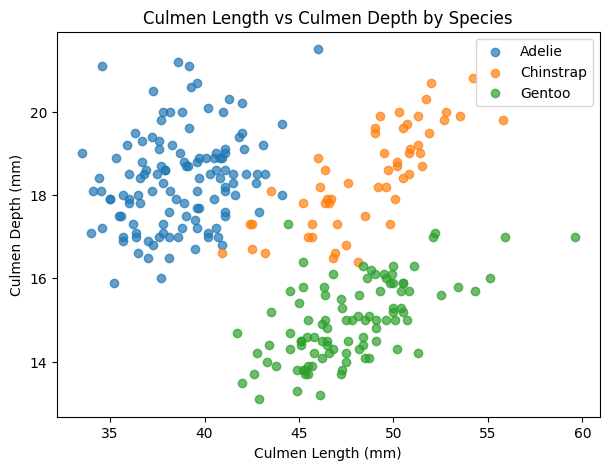

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for species in train["Species"].unique():
    subset = train[train["Species"] == species]
    
    ax.scatter(
        subset["Culmen Length (mm)"],
        subset["Culmen Depth (mm)"],
        label=species,
        alpha=0.7
    )

ax.set_xlabel("Culmen Length (mm)")
ax.set_ylabel("Culmen Depth (mm)")
ax.set_title("Culmen Length vs Culmen Depth by Species")
ax.legend()

plt.show()

The scatterplot shows that culmen length and culmen depth help separate the penguin species. Gentoo penguins appear separated from the other species with lower culmen depth and on the higher end of culmen length, while Adelie and Chinstrap penguins have more overlap. Given that these features appear to create distinct clusters for each penguin species, we consider them promising quantitative candidates for our future models.

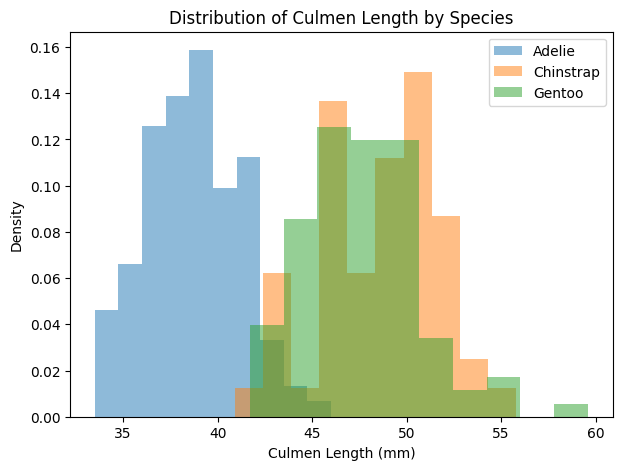

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

for species in train["Species"].unique():
    subset = train[train["Species"] == species]
    
    ax.hist(
        subset["Culmen Length (mm)"],
        label=species,
        alpha=0.5,
        density=True
    )

ax.set_xlabel("Culmen Length (mm)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Culmen Length by Species")
ax.legend()

plt.show()

The histogram shows the species distributions of culmen length and how they differ. Adelie penguins tend to have shorter culmens, while Chinstrap and Gentoo penguins generally have longer culmens. This supports using culmen length as one of our quantitative features even before considering our additional features of choice.

/var/folders/r6/n0wh2lcs2dl98_73bdgpck3h0000gn/T/ipykernel_69849/1008981187.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=species_list)


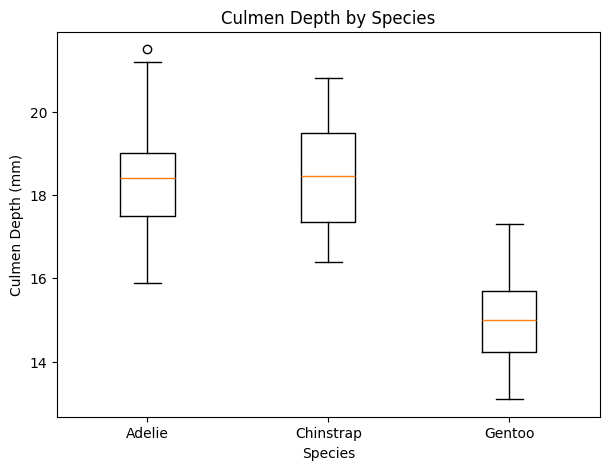

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

species_list = train["Species"].unique()

data = []

for species in species_list:
    subset = train[train["Species"] == species]
    data.append(subset["Culmen Depth (mm)"])

ax.boxplot(data, labels=species_list)

ax.set_xlabel("Species")
ax.set_ylabel("Culmen Depth (mm)")
ax.set_title("Culmen Depth by Species")

plt.show()

This boxplot compares culmen depth across the three species. The species show different typical culmen depths, although Adelie and Chinstrap are more similar than Gentoo which has a smaller culmen depth. This suggests that culmen depth may help the model distinguish species, especially when combined with culmen length and island.

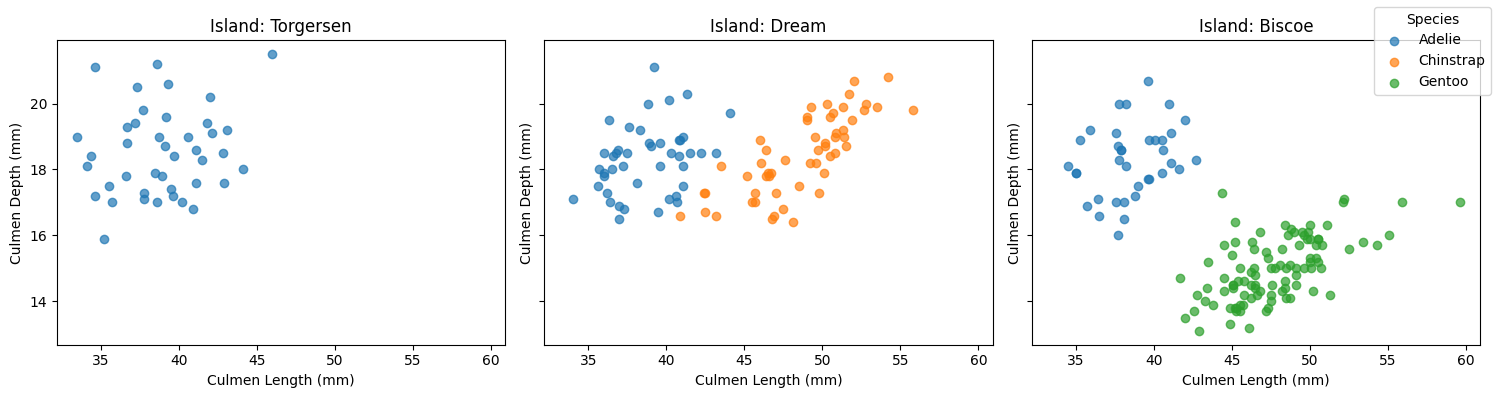

In [11]:
islands = train["Island"].unique()

fig, axes = plt.subplots(
    1,
    len(islands),
    figsize=(5 * len(islands), 4),
    sharex=True,
    sharey=True
)

for ax, island in zip(axes, islands):
    island_data = train[train["Island"] == island]
    
    for species in train["Species"].unique():
        subset = island_data[island_data["Species"] == species]
        
        ax.scatter(
            subset["Culmen Length (mm)"],
            subset["Culmen Depth (mm)"],
            label=species,
            alpha=0.7
        )
    
    ax.set_title(f"Island: {island}")
    ax.set_xlabel("Culmen Length (mm)")
    ax.set_ylabel("Culmen Depth (mm)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Species", loc="upper right")

plt.tight_layout()
plt.show()

This multiple-axis figure shows the relationship between culmen length and culmen depth separately for each island. We see that Torgersen Island contains only Adelie penguins, Dream Island contains Adelie and Chinstrap penguins, and Biscoe Island contains Adelie and Gentoo penguins. We see that the distribution of species differs by land, which provides useful information for predicting species. This shows that island is a strong candidate for our qualitative feature for our models

In [12]:
summary_table = train.groupby(["Species", "Island"])[
    ["Culmen Length (mm)", "Culmen Depth (mm)"]
].mean()

summary_table

Culmen Length (mm)  Culmen Depth (mm)
Species   Island                                          
Adelie    Biscoe              38.513889          18.266667
          Dream               38.720455          18.304545
          Torgersen           38.909756          18.531707
Chinstrap Dream               48.600000          18.440741
Gentoo    Biscoe              47.723469          14.987755

This table gives the average culmen length and culmen depth for each species on each island. The averages differ across both species and islands, which supports our previous visualizations. Consequently, this supports our decision to use Island, Culmen Length, and Culmen Depth as our three features. 

## **4. Feature Selection**

For this example, we selected Island as the qualitative feature and Culmen Length and Culmen Depth as the two quantitative features. Using our exploratory scatterplots, we showed that culmen length and culmen depth help separate the species. The multiple-axis plot and groupby table also showed that island is related to species distribution. Therefore, these three features seem reasonable for predicting penguin species while using only three measurements per penguin.

In [13]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

class_order = sorted(y_train.unique())

class_order

['Adelie', 'Chinstrap', 'Gentoo']

In [14]:
qualitative_features = ["Island"]

quantitative_features = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("qual", OneHotEncoder(handle_unknown="ignore"), qualitative_features),
        ("quant", StandardScaler(), quantitative_features)
    ]
)

## **5. Modeling**

In this section, we train three machine learning models: logistic regression, K-nearest neighbors, and support vector machine. For each model, we use cross-validation to choose model parameters, evaluate the final model on unseen test data, display a confusion matrix, and plot decision regions. 

In [15]:
def train_and_evaluate_model(model_name, classifier, param_grid):
    """
    Train a model using cross-validation and evaluate it on the test data.

    Parameters:
    model_name: a string name for the model
    classifier: the sklearn classifier
    param_grid: dictionary of parameters for GridSearchCV

    Returns:
    best_model: the best trained model after cross-validation
    """
    
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )
    
    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=5
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(X_test)
    
    test_accuracy = accuracy_score(y_test, y_pred)
    
    print("Model:", model_name)
    print("Best parameters:", grid.best_params_)
    print("Best cross-validation score:", grid.best_score_)
    print("Test accuracy:", test_accuracy)
    
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_order
    )
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_order
    )
    
    disp.plot()
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()
    
    return best_model

In [16]:
def plot_decision_regions(model, data, model_name):
    """
    Plot decision regions for a model.

    Since the model uses one qualitative feature and two quantitative features,
    this function creates one decision region plot for each island.
    """
    
    x_feature = "Culmen Length (mm)"
    y_feature = "Culmen Depth (mm)"
    qualitative_feature = "Island"
    
    islands = sorted(data[qualitative_feature].unique())
    
    color_map = ListedColormap(["#FFAAAA", "#AAFFAA", "#AAAAFF"])
    point_colors = {
        class_order[0]: "#AA0000",
        class_order[1]: "#00AA00",
        class_order[2]: "#0000AA"
    }
    
    x_min = data[x_feature].min() - 1
    x_max = data[x_feature].max() + 1
    y_min = data[y_feature].min() - 1
    y_max = data[y_feature].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    fig, axes = plt.subplots(
        1,
        len(islands),
        figsize=(5 * len(islands), 4),
        sharex=True,
        sharey=True
    )
    
    if len(islands) == 1:
        axes = [axes]
    
    class_to_number = {
        species: i for i, species in enumerate(class_order)
    }
    
    for ax, island in zip(axes, islands):
        
        grid_df = pd.DataFrame({
            qualitative_feature: island,
            x_feature: xx.ravel(),
            y_feature: yy.ravel()
        })
        
        predictions = model.predict(grid_df)
        
        prediction_numbers = np.array([
            class_to_number[pred] for pred in predictions
        ])
        
        prediction_numbers = prediction_numbers.reshape(xx.shape)
        
        ax.contourf(
            xx,
            yy,
            prediction_numbers,
            cmap=color_map,
            alpha=0.35,
            levels=np.arange(len(class_order) + 1) - 0.5
        )
        
        island_data = data[data[qualitative_feature] == island]
        
        for species in class_order:
            species_data = island_data[island_data[target] == species]
            
            ax.scatter(
                species_data[x_feature],
                species_data[y_feature],
                label=species,
                color=point_colors[species],
                edgecolor="black",
                alpha=0.8
            )
        
        ax.set_title(f"{model_name}: {island}")
        ax.set_xlabel(x_feature)
        ax.set_ylabel(y_feature)
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Species", loc="upper right")
    
    plt.tight_layout()
    plt.show()

### Model 1: Logistic Regression

Logistic Regression is a classification model that will estimate the probability that an observation belongs to each penguin species and predict the species with the largest estimated probability. Also, logistic regression creates linear decision boundaries which makes it easy to interpret results.

Model: Logistic Regression
Best parameters: {'classifier__C': 10}
Best cross-validation score: 0.9963636363636365
Test accuracy: 1.0


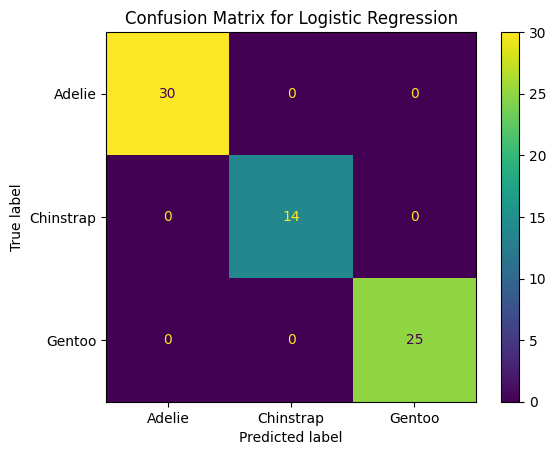

In [17]:
logistic_model = train_and_evaluate_model(
    model_name="Logistic Regression",
    classifier=LogisticRegression(max_iter=1000),
    param_grid={
        "classifier__C": [0.01, 0.1, 1, 10, 100]
    }
)

The confusion matrix shows that the Logistic Regression model correctly classified every penguin in the testing data set. Given this, we have a test accuracy of 100%. 

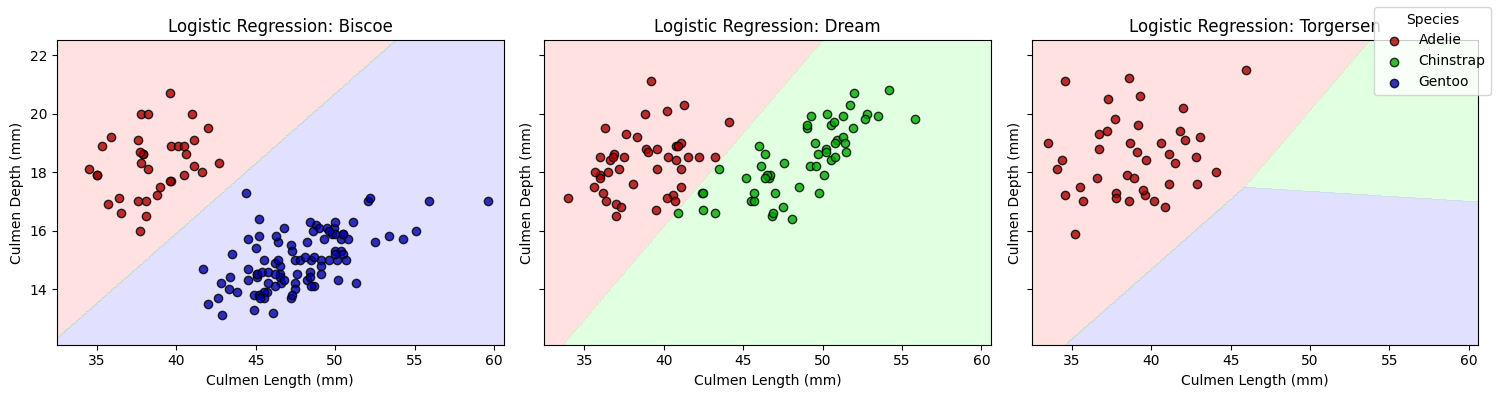

In [18]:
plot_decision_regions(
    logistic_model,
    train,
    "Logistic Regression"
)

The logistic regression model uses linear boundaries to separate the species. Its decision regions are relatively smooth and simple. This makes the model easy to interpret, but it may struggle if the true separation between species is more complicated with more overlap. We noticed that the regions where Adelie and Chinstrap penguins approach could indicate future misclassifications. Overall, we note the strong performance of the logistic regression model.

### Model 2: K-Nearest Neighbors

K-Nearest Neighbors (KNN) is a model that classifies penguins by examining species labels of nearby observations in the training data. KNN bases its predictions on local "neighborhoods" in the feature space. This model allows for more flexible decision boundaries when comparing to the Logistic Regression Model. However, KNN is also sensitive to noise if there are few neighbors.

Model: K-Nearest Neighbors
Best parameters: {'classifier__n_neighbors': 9}
Best cross-validation score: 0.989090909090909
Test accuracy: 1.0


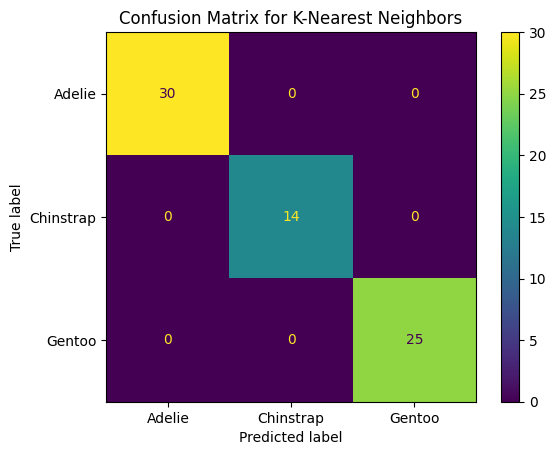

In [19]:
knn_model = train_and_evaluate_model(
    model_name="K-Nearest Neighbors",
    classifier=KNeighborsClassifier(),
    param_grid={
        "classifier__n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15]
    }
)

The confusion matrix indicates that KNN performed a perfect classification on the testing data. This is the same result as with the Logistic Regression model.

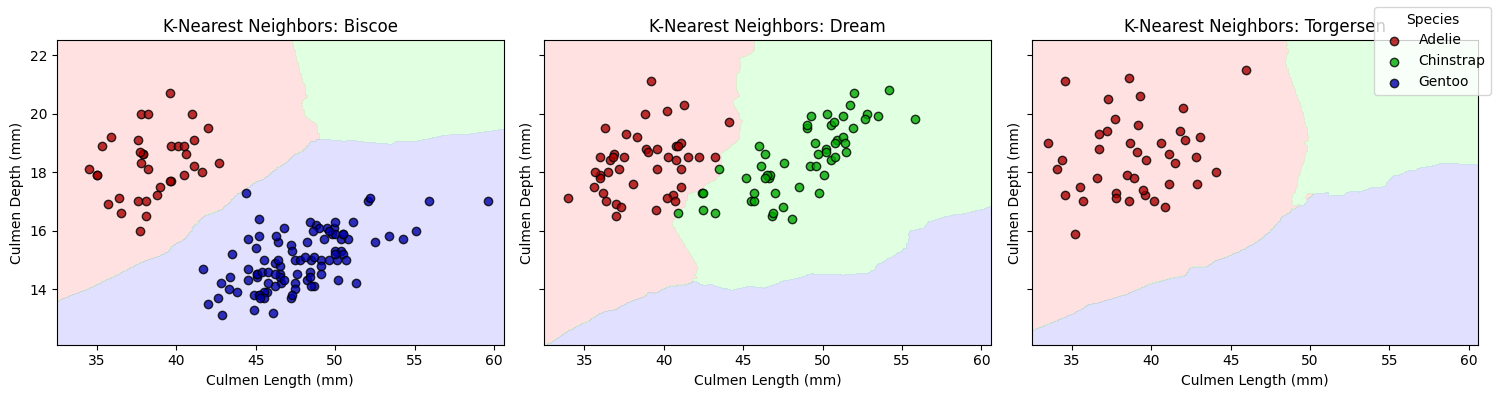

In [20]:
plot_decision_regions(
    knn_model,
    train,
    "K-Nearest Neighbors"
)

The K-nearest neighbors model classifies a penguin based on nearby penguins in the training data. Its decision regions can be more flexible than logistic regression. This flexibility allows the model to shape a local structure in the data. Even though no testing errors occurred we note that the irregular boundaries suggest KNN might be sensitive to individual observations and overfit if we have too little neighbors. Despite this, we note that KNN performed well on the penguins dataset.

### Model 3: Support Vector Machine

Support Vector Machines (SVMs) work to create separate classes by making decision boundaries that maximize separations between groups. SVMs use an RBF kernel that allows the model to make curved boundaries instead of strictly linear boundaries. This adds flexibility that can capture more complex relationships between features when they cannot be separated by straight lines.

Model: Support Vector Machine
Best parameters: {'classifier__C': 100, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
Best cross-validation score: 0.9927272727272728
Test accuracy: 0.9855072463768116


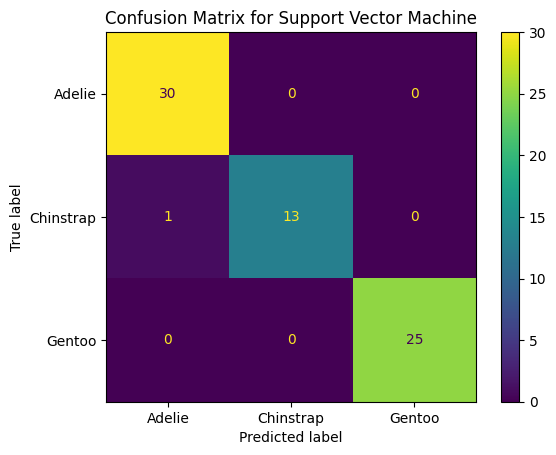

In [21]:
svm_model = train_and_evaluate_model(
    model_name="Support Vector Machine",
    classifier=SVC(),
    param_grid={
        "classifier__C": [0.1, 1, 10, 100],
        "classifier__gamma": [0.01, 0.1, 1, 10],
        "classifier__kernel": ["rbf"]
    }
)

From the confusion matrix we see that the SVM model did not perform perfectly like Logistic Regression or KNN. One misclassification was made.

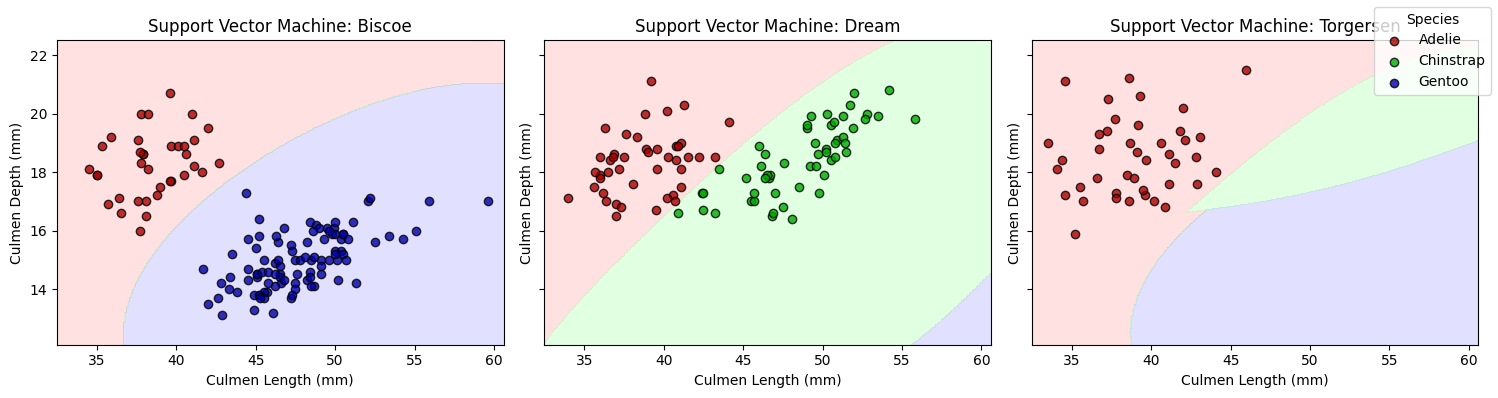

In [22]:
plot_decision_regions(
    svm_model,
    train,
    "Support Vector Machine"
)

The support vector machine creates curved decision boundaries because we used an RBF kernel, which allows the model to capture complex patterns. Despite this, this additional flexibility did not provide an advantage compared to Logistic Regression or KNN models.

In [23]:
models = {
    "Logistic Regression": logistic_model,
    "K-Nearest Neighbors": knn_model,
    "Support Vector Machine": svm_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(name, "test accuracy:", acc)

Logistic Regression test accuracy: 1.0
K-Nearest Neighbors test accuracy: 1.0
Support Vector Machine test accuracy: 0.9855072463768116


All of our chosen models achieved high predictive performance using our three features: island, Culmen Depth, and Culmen Length. All models gave a test accuracy above 95%. Logistic Regression and KNN both achieved perfect testing accuracy, while the SVM model reached 98.6% accuracy.

## **6. Discussion**

The goal of the project was to use a small number of measurements to classify penguin species. This included using one qualitative measurement, Island, and two quantitative measurements, Culmen Length and Culmen Depth. We affirmed our choices using exploratory analysis to demonstrate that all three of these features provided meaningful separation between Adelie, Chinstrap, and Gentoo penguins. 

Overall, all three models attempted to predict penguin species using only one qualitative feature, Island, and two quantitative features, Culmen Length and Culmen Depth. This satisfies the project goal of using a small number of measurements to classify penguin species. Logistic Regression and KNN both achieved 100% accuracy on the testing data and the SVM model achieved 98.6% accuracy. Our confusion matrices showed which species each model classified correctly and which species got confused. In general, mistakes are most likely to occur where species overlap in culmen length and culmen depth. The decision region plots helped to explain these mistakes by providing visualizations of the boundaries where the model changes from predicting one species to another.

While both Logistic Regression and KNN achieved perfect testing accuracy, we would recommend Logistic Regression as the final model with Island, Culmen Length, and Culmen Depth as the features. Using these features and the Logistic Regression model, we were able to achieve perfect predictive performance with simple and interpretable decision boundaries. 

From this analysis, we note that to achieve accurate penguin classification we do not need a large number of features. With only Island, Culmen Length, and Culmen Depth we could sufficiently achieve accuracy about 95% across all three models. This conclusion supports the project goal of identifying a small set of measurements to predict penguin species. 

If additional data were available, model performance could improve by incorporating additional biological measurements such as flipper length or body mass. Model performance could also improve with observations from each island or repeated measurements collected across different years. Additional work may explore whether the high performance we produced can be achieved without using island information.